<a href="https://colab.research.google.com/github/Rodicahyawan/Machine-Learning---Maternal-Health-Risk-Analysis/blob/main/Maternal%20Health%20Risk%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Preprocessing dan Eksplorasi Data

https://archive.ics.uci.edu/dataset/863/maternal+health+risk

In [ ]:
import pandas as pd

# Load dataset
file_path = 'MaternalHealthRiskDataSet.csv'
data = pd.read_csv(file_path)


In [ ]:
# Memastikan nama kolom bebas spasi dan rapi, sehingga mempermudah manipulasi data.
data.columns = data.columns.str.strip().str.replace(' ', '')

# Menampilkan semua nama kolom setelah proses pembersihan dalam bentuk daftar
print("Kolom dalam dataset setelah preprocessing:", data.columns.tolist())


Kolom dalam dataset setelah preprocessing: ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate', 'RiskLevel']


In [ ]:
# Memastikan tidak ada data yang hilang (missing values).
missing_values = data.isnull().sum()
print("\nMissing values in each column:\n", missing_values)



Missing values in each column:
 Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64


In [ ]:
# Eksplorasi Data Awal (EDA)
# Memahami karakteristik awal dataset.

print("\nBasic statistics of the dataset:\n", data.describe())


Basic statistics of the dataset:
                Age   SystolicBP  DiastolicBP           BS     BodyTemp  \
count  1014.000000  1014.000000  1014.000000  1014.000000  1014.000000   
mean     29.871795   113.198225    76.460552     8.725986    98.665089   
std      13.474386    18.403913    13.885796     3.293532     1.371384   
min      10.000000    70.000000    49.000000     6.000000    98.000000   
25%      19.000000   100.000000    65.000000     6.900000    98.000000   
50%      26.000000   120.000000    80.000000     7.500000    98.000000   
75%      39.000000   120.000000    90.000000     8.000000    98.000000   
max      70.000000   160.000000   100.000000    19.000000   103.000000   

         HeartRate  
count  1014.000000  
mean     74.301775  
std       8.088702  
min       7.000000  
25%      70.000000  
50%      76.000000  
75%      80.000000  
max      90.000000  


In [ ]:
print("\nFirst few rows of the dataset:\n", data.head())


First few rows of the dataset:
    Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate  RiskLevel
0   25         130           80  15.0      98.0         86  high risk
1   35         140           90  13.0      98.0         70  high risk
2   29          90           70   8.0     100.0         80  high risk
3   30         140           85   7.0      98.0         70  high risk
4   35         120           60   6.1      98.0         76   low risk


In [ ]:
print("\nDataset info:")
print(data.info())



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB
None


In [ ]:
# Memastikan kolom target (RiskLevel) ada dalam dataset.
if 'RiskLevel' in data.columns:
    print("\nKolom 'RiskLevel' ditemukan.")
    # Memeriksa keberadaan kolom RiskLevel menggunakan in.
    print("Unique values in 'RiskLevel':", data['RiskLevel'].unique())
else:
    # If the column is not found, raise an error and display available columns for debugging
    raise ValueError(f"Error: 'RiskLevel' column not found in the dataset. Available columns: {data.columns.tolist()}")



Kolom 'RiskLevel' ditemukan.
Unique values in 'RiskLevel': ['high risk' 'low risk' 'mid risk']


In [ ]:
#  Memisahkan variabel independen (fitur) dan target (label).

X = data.drop(columns=['RiskLevel']) #menyimpan semua kolom kecuali RiskLev
y = data['RiskLevel']  #menyimpan kolom target RiskLevel.

In [ ]:
# Mengubah kolom target menjadi format numerik jika berbentuk kategorikal.
#Menggunakan pd.get_dummies() untuk membuat encoding one-hot pada variabel target.

# Encode target variable (if categorical)
y_encoded = pd.get_dummies(y, drop_first=False)

# Display encoded target variable
print("\nEncoded target variable (first few rows):\n", y_encoded.head())


Encoded target variable (first few rows):
    high risk  low risk  mid risk
0       True     False     False
1       True     False     False
2       True     False     False
3       True     False     False
4      False      True     False


# Pembangunan Model Baseline

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
#Memuat dataset dari file CSV dan memastikan nama kolom konsisten (tanpa spasi).

# Load your dataset (Pastikan file CSV ada di direktori yang sesuai)
file_path = 'MaternalHealthRiskDataSet.csv'
data = pd.read_csv(file_path)

# Preprocessing: Clean column names (remove spaces and ensure consistency)
data.columns = data.columns.str.strip().str.replace(' ', '') #membersihkan nama kolom.


In [ ]:
# Memisahkan data menjadi fitur (X) dan target (y).

# Separate features and target variable
X = data.drop(columns=['RiskLevel'])#memisahkan kolom fitur.

# Encode target variable
y_encoded = pd.get_dummies(y, drop_first=False)#mengonversi target menjadi encoding one-hot.


In [ ]:
#  Membagi dataset menjadi data latih dan uji.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#train_test_split() membagi data dengan rasio 80% untuk latih, 20% untuk uji.
#random_state=42 memastikan pembagian data konsisten.

In [ ]:
#melatih model Random Forest dan membuat prediksi
# Train baseline Random Forest model
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)#dengan 100 pohon keputusan digunakan sebagai baseline.
rf_baseline.fit(X_train, y_train)

# Predict on test data
y_pred_baseline = rf_baseline.predict(X_test) #predict() menghasilkan prediksi pada data uji.

print("Baseline model training complete.")


Baseline model training complete.


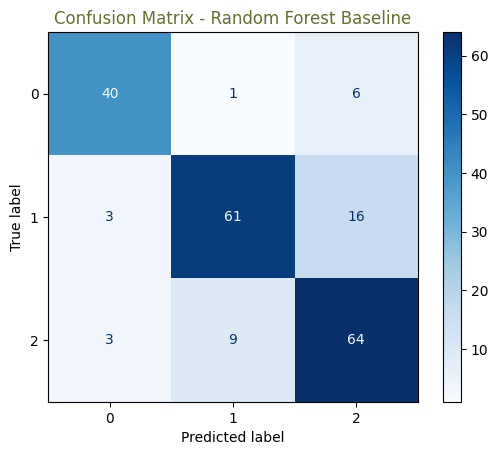

In [ ]:
# Mengevaluasi performa model melalui confusion matrix.

cm = confusion_matrix(y_test, y_pred_baseline)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Random Forest Baseline", color="#657131")
plt.show()


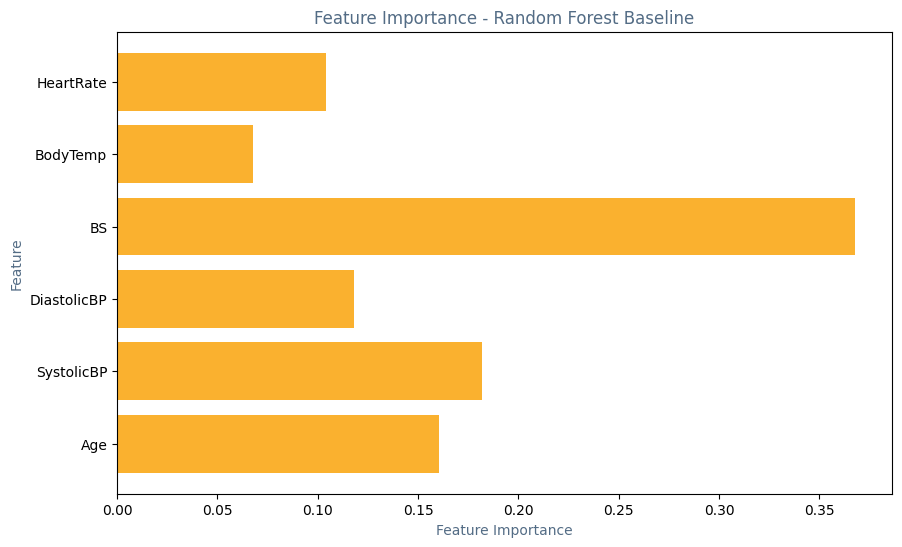

In [ ]:
#Mengidentifikasi fitur paling penting dalam model.
importances = rf_baseline.feature_importances_ #feature_importances_ menghitung kontribusi masing-masing fitur.
feature_names = X.columns

plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances, color="#FAB12F") #barh() membuat diagram batang horizontal.
plt.xlabel("Feature Importance", color="#536c85")
plt.ylabel("Feature", color="#536c85")
plt.title("Feature Importance - Random Forest Baseline", color="#536c85")
plt.show()


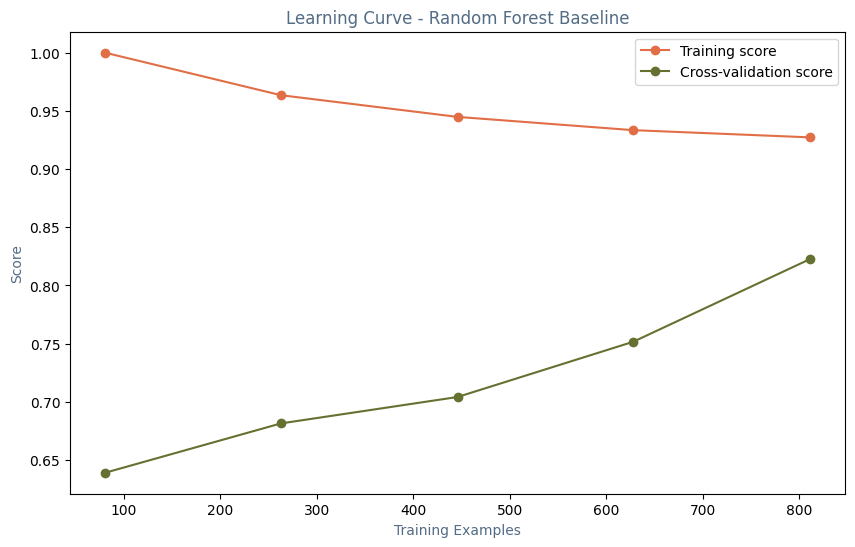

In [ ]:
#Memahami performa model seiring bertambahnya data latih.

train_sizes, train_scores, test_scores = learning_curve( #learning_curve() menghitung skor pelatihan dan validasi.
    rf_baseline, X, y, cv=5, scoring='accuracy', n_jobs=-1
)

train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color="#e16e46", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="#657131", label="Cross-validation score")
plt.title("Learning Curve - Random Forest Baseline", color="#536c85")
plt.xlabel("Training Examples", color="#536c85")
plt.ylabel("Score", color="#536c85")
plt.legend(loc="best")
plt.show()


# Eksplorasi Model

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Load your dataset (Pastikan file CSV ada di direktori yang sesuai)
file_path = 'MaternalHealthRiskDataSet.csv'  # Ganti dengan path file yang sesuai
data = pd.read_csv(file_path)

# Preprocessing: Clean column names (remove spaces and ensure consistency)
data.columns = data.columns.str.strip().str.replace(' ', '')


In [ ]:
# Separate features and target variable
X = data.drop(columns=['RiskLevel'])
y = data['RiskLevel']


In [ ]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Define hyperparameters for exploration (Model 1)
param_grid_1 = {
    'n_estimators': [50, 100, 150],  # Jumlah pohon dalam hutan
    'max_depth': [None, 10, 20],     # Kedalaman maksimum dari setiap pohon
    'min_samples_split': [2, 5, 10]  # Minimum jumlah sampel untuk membagi node
}


# Perform Grid Search for Model 1
grid_search_1 = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                             param_grid=param_grid_1,
                             cv=3,
                             scoring='accuracy',
                             verbose=2)

grid_search_1.fit(X_train, y_train)

# Best model for Model 1
best_rf_model_1 = grid_search_1.best_estimator_
print("Best parameters for Model 1:", grid_search_1.best_params_)
print("Best cross-validation score for Model 1:", grid_search_1.best_score_)


Fitting 3 folds for each of 27 candidates, totalling 81 fits
[CV] END max_depth=None, min_samples_split=2, n_estimators=50; total time=   0.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=50; total time=   0.2s
[CV] END max_depth=None, min_samples_split=2, n_estimators=50; total time=   0.2s
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, min_samples_split=2, n_estimators=150; total time=   0.3s
[CV] END max_depth=None, min_samples_split=2, n_estimators=150; total time=   0.3s
[CV] END max_depth=None, min_samples_split=2, n_estimators=150; total time=   0.3s
[CV] END max_depth=None, min_samples_split=5, n_estimators=50; total time=   0.1s
[CV] END max_depth=None, min_samples_split=5, n_estimators=50; total time=   0.1s
[CV] END max_depth=None, min_sa

In [ ]:
# Define hyperparameters for exploration (Model 2)
param_grid_2 = {
    'n_estimators': [100, 150, 200],  # Larger number of estimators
    'max_depth': [None, 5, 15],        # Smaller max depth
    'min_samples_split': [2, 10, 15]   # Different sample splits
}

# Perform Grid Search for Model 2
grid_search_2 = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                             param_grid=param_grid_2,
                             cv=3,
                             scoring='accuracy',
                             verbose=2)

grid_search_2.fit(X_train, y_train)

# Best model for Model 2
best_rf_model_2 = grid_search_2.best_estimator_
print("Best parameters for Model 2:", grid_search_2.best_params_)
print("Best cross-validation score for Model 2:", grid_search_2.best_score_)


Fitting 3 folds for each of 27 candidates, totalling 81 fits
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, min_samples_split=2, n_estimators=150; total time=   0.3s
[CV] END max_depth=None, min_samples_split=2, n_estimators=150; total time=   0.3s
[CV] END max_depth=None, min_samples_split=2, n_estimators=150; total time=   0.3s
[CV] END max_depth=None, min_samples_split=2, n_estimators=200; total time=   0.4s
[CV] END max_depth=None, min_samples_split=2, n_estimators=200; total time=   0.4s
[CV] END max_depth=None, min_samples_split=2, n_estimators=200; total time=   0.5s
[CV] END max_depth=None, min_samples_split=10, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, min_samples_split=10, n_estimators=100; total time=   0.3s
[CV] END max_depth=None,

In [ ]:
# Define hyperparameters for exploration (Model 3)
param_grid_3 = {
    'n_estimators': [200, 250, 300],  # Larger number of estimators
    'max_depth': [None, 10, 30],       # Larger max depth
    'min_samples_split': [5, 15, 20]   # Different sample splits
}

# Perform Grid Search for Model 3
grid_search_3 = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                             param_grid=param_grid_3,
                             cv=3,
                             scoring='accuracy',
                             verbose=2)

grid_search_3.fit(X_train, y_train)

# Best model for Model 3
best_rf_model_3 = grid_search_3.best_estimator_
print("Best parameters for Model 3:", grid_search_3.best_params_)
print("Best cross-validation score for Model 3:", grid_search_3.best_score_)


Fitting 3 folds for each of 27 candidates, totalling 81 fits
[CV] END max_depth=None, min_samples_split=5, n_estimators=200; total time=   0.4s
[CV] END max_depth=None, min_samples_split=5, n_estimators=200; total time=   0.4s
[CV] END max_depth=None, min_samples_split=5, n_estimators=200; total time=   0.4s
[CV] END max_depth=None, min_samples_split=5, n_estimators=250; total time=   0.5s
[CV] END max_depth=None, min_samples_split=5, n_estimators=250; total time=   0.5s
[CV] END max_depth=None, min_samples_split=5, n_estimators=250; total time=   0.5s
[CV] END max_depth=None, min_samples_split=5, n_estimators=300; total time=   0.6s
[CV] END max_depth=None, min_samples_split=5, n_estimators=300; total time=   0.6s
[CV] END max_depth=None, min_samples_split=5, n_estimators=300; total time=   0.6s
[CV] END max_depth=None, min_samples_split=15, n_estimators=200; total time=   0.4s
[CV] END max_depth=None, min_samples_split=15, n_estimators=200; total time=   0.4s
[CV] END max_depth=None,

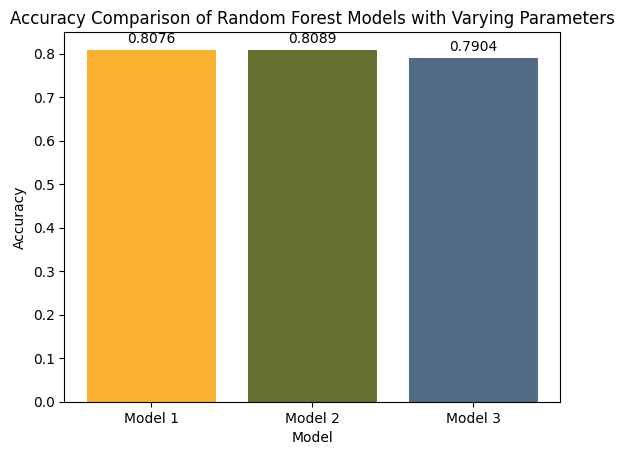

In [ ]:
# Visualize the accuracy for all models
scores = [
    grid_search_1.best_score_,
    grid_search_2.best_score_,
    grid_search_3.best_score_
]

models = ['Model 1', 'Model 2', 'Model 3']

pastel_green_colors = ['#FAB12F', '#657131', '#536c85']

plt.bar(models, scores, color=pastel_green_colors)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison of Random Forest Models with Varying Parameters')

# Display accuracy on top of each bar
for i in range(len(models)):
    plt.text(i, scores[i] + 0.01, f'{scores[i]:.4f}', ha='center', va='bottom')

plt.show()


# Evaluasi

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [ ]:
# Function to evaluate a model
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)  # Model menghasilkan label prediksi

    # Hasil prediksi dan data sebenarnya
    y_pred_labels = y_pred
    y_test_labels = y_test

    # Menghitung metrik evaluasi
    accuracy = accuracy_score(y_test_labels, y_pred_labels)
    precision = precision_score(y_test_labels, y_pred_labels, average='weighted')  # Cocok untuk dataset tidak seimbang
    recall = recall_score(y_test_labels, y_pred_labels, average='weighted')
    f1 = f1_score(y_test_labels, y_pred_labels, average='weighted')

    # Menampilkan metrik evaluasi
    print(f"{model_name} Accuracy: {accuracy * 100:.2f}%")
    print(f"{model_name} Precision: {precision:.4f}")
    print(f"{model_name} Recall: {recall:.4f}")
    print(f"{model_name} F1-Score: {f1:.4f}")

    # Menampilkan laporan klasifikasi
    print(f"\nClassification Report for {model_name}:")
    print(classification_report(y_test_labels, y_pred_labels))

    # Membuat dan menampilkan confusion matrix
    cm = confusion_matrix(y_test_labels, y_pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_test.unique())
    disp.plot(cmap=plt.cm.Greens)
    plt.title(f"Confusion Matrix for {model_name}")
    plt.show()

    return accuracy, precision, recall, f1


Evaluating Model 1...
Model 1 Accuracy: 81.28%
Model 1 Precision: 0.8185
Model 1 Recall: 0.8128
Model 1 F1-Score: 0.8134

Classification Report for Model 1:
              precision    recall  f1-score   support

   high risk       0.87      0.85      0.86        47
    low risk       0.86      0.76      0.81        80
    mid risk       0.74      0.84      0.79        76

    accuracy                           0.81       203
   macro avg       0.82      0.82      0.82       203
weighted avg       0.82      0.81      0.81       203



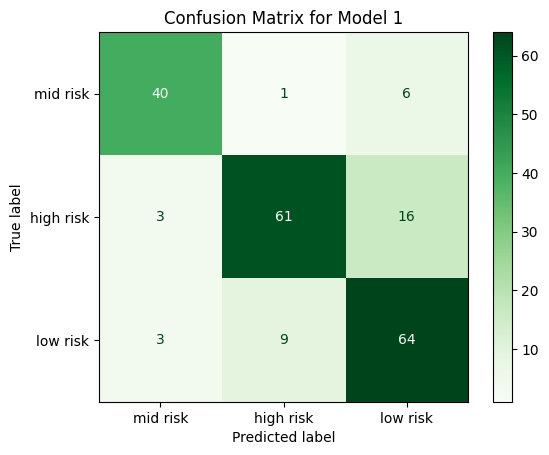

In [ ]:
# Evaluate Model 1
print("Evaluating Model 1...")
accuracy_1, precision_1, recall_1, f1_1 = evaluate_model(best_rf_model_1, X_test, y_test, "Model 1")


Evaluating Model 2...
Model 2 Accuracy: 81.28%
Model 2 Precision: 0.8185
Model 2 Recall: 0.8128
Model 2 F1-Score: 0.8134

Classification Report for Model 2:
              precision    recall  f1-score   support

   high risk       0.87      0.85      0.86        47
    low risk       0.86      0.76      0.81        80
    mid risk       0.74      0.84      0.79        76

    accuracy                           0.81       203
   macro avg       0.82      0.82      0.82       203
weighted avg       0.82      0.81      0.81       203



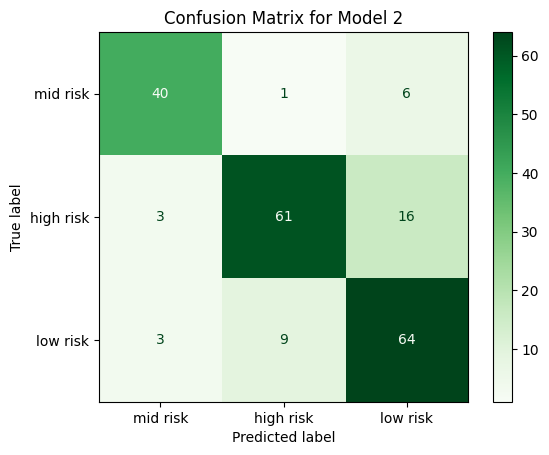

In [ ]:
# Evaluate Model 2
print("Evaluating Model 2...")
accuracy_2, precision_2, recall_2, f1_2 = evaluate_model(best_rf_model_2, X_test, y_test, "Model 2")

Evaluating Model 3...
Model 3 Accuracy: 80.30%
Model 3 Precision: 0.8076
Model 3 Recall: 0.8030
Model 3 F1-Score: 0.8036

Classification Report for Model 3:
              precision    recall  f1-score   support

   high risk       0.89      0.83      0.86        47
    low risk       0.82      0.76      0.79        80
    mid risk       0.74      0.83      0.78        76

    accuracy                           0.80       203
   macro avg       0.82      0.81      0.81       203
weighted avg       0.81      0.80      0.80       203



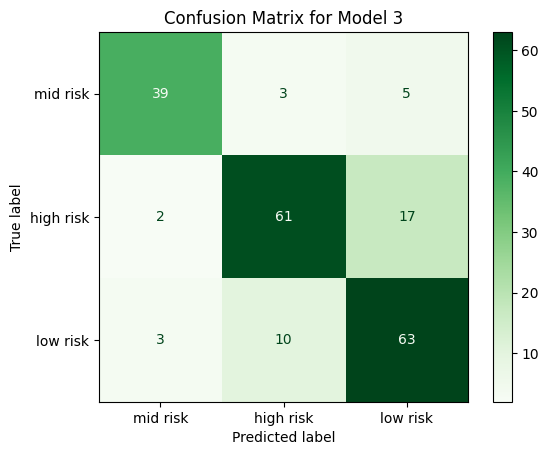

In [ ]:
# Evaluate Model 3
print("Evaluating Model 3...")
accuracy_3, precision_3, recall_3, f1_3 = evaluate_model(best_rf_model_3, X_test, y_test, "Model 3")
